In [1]:
import pandas as pd
import nltk
import re
import string

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer

In [ ]:
# Load the dataset
news = pd.read_csv("trainset.txt", sep="\t", header=None, names=["CLASS", "TITLE", "DATE", "BODY"])

news.head()

,CLASS,TITLE,DATE,BODY
0,1,JAPAN FIRM PLANS TO SELL U.S. FARMLAND TO JAP...,"MORIOKA, Japan, March 12 -",A Japanese real estate company said it will ...
1,-1,NORTH BH SETS ONE-FOR-FIVE OFFER FOR NORGOLD ...,"MELBOURNE, March 12 -",North Broken Hill Holdings Ltd & lt;NBHA.ME ...
2,-1,OUTOKUMPU IN COPPER DEAL WITH IBERICA DEL COBRE,"HELSINKI, June 26 -",Finland's state-owned mining company Outokum...
3,1,ROTTERDAM GRAIN HANDLER SAYS PORT BALANCE ROSE,"ROTTERDAM, April 13 -","Graan Elevator Mij, GEM, said its balance in..."
4,1,U.S. SENATE PANEL VOTES TO LIMIT COUNTY LOAN ...,(NO DATE),(NO TEXT)


In [ ]:
# Separate features and labels
texts = news["BODY"]
labels = news["CLASS"]

texts.head()

0     A Japanese real estate company  said it will ...
1     North Broken Hill Holdings Ltd  & lt;NBHA.ME ...
2     Finland's state-owned mining company  Outokum...
3     Graan Elevator Mij, GEM, said its  balance in...
4                                            (NO TEXT)
Name: BODY, dtype: object

In [4]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
# Get the English stop words
stop_words = set(stopwords.words('english'))
print(stop_words)  

{'no', 'to', 'or', 'then', 'too', "you're", 'up', "you'd", 'at', 'any', 'over', 'should', 'his', 'being', "she'll", 'y', "i'm", "you'll", 'further', 'did', 'ourselves', 'of', 'why', 've', 'other', 'i', "shouldn't", 're', 'm', 'all', "aren't", 'more', 'under', 'during', 'needn', 'a', 'until', 'down', 'those', 'into', 'because', 'these', 'you', 'your', 'than', 'whom', 'he', 'wouldn', 'theirs', 'nor', "we'll", 'such', 'on', 'which', 'were', 'through', 'in', 'who', "you've", 'what', 'the', 'o', 'once', 'an', 'do', 'my', 'there', 'wasn', 'does', 'just', "mightn't", "they're", 'd', 'shan', 'herself', 'been', 'by', 'very', "we're", 'doesn', 'so', "hasn't", 'hers', 'didn', "couldn't", "we've", "it'd", "hadn't", 'yours', "mustn't", 'our', 'ain', 'we', "they've", "weren't", 't', 'again', 'between', 'above', 'll', 'its', 'both', 'when', 'won', 'had', "they'll", 'was', 'off', 'don', 'own', 'some', 'aren', 'itself', 'now', 'couldn', "wouldn't", 'after', 'isn', 'them', "we'd", 'each', 'themselves', 

In [ ]:
# Preprocess the text data
def preprocess_text(text):
	text = text.lower()
	text = re.sub(f"[{re.escape(string.punctuation)}]", "", text)
	tokens = text.split()
	tokens = [word for word in tokens if word not in stop_words]
	text = ' '.join(tokens)
	return text

preprocessed_texts = texts.apply(preprocess_text)        

print(texts[0])
print(preprocessed_texts[0])

 A Japanese real estate company  said it will launch a campaign to sell land in U.S. Farming  areas to rich Japanese.  Higashi Nippon House said it would offer around 2,200 acres  of land in Illinois, California, Florida and Indiana from early  April to gauge response. It set up International Farm Corp of  America in Chicago last September to oversee the operation.  American farmers would continue as working tenants and part  of the profits from harvests of rice, corn, soybean and oranges  would go to the Japanese investors as rental.  Japanese Agriculture Ministry officials told Reuters sales  were limited to farmers to keep land in agricultural use.  "Two years ago, I began to seek my own farmland in Japan,"  said Isao Nakamura, president of Higashi Nippon. "However, sale  of Japanese farmland is strictly controlled by the government,  so I began to look for the land in the U.S to make my dream to  own farm land come true."  Nakamura said hundreds of companies exist in the U.S. To  s

Stemming


In [ ]:
stemmer = PorterStemmer()

def preprocess_text(text):
	text = text.lower()
	text = re.sub(f"[{re.escape(string.punctuation)}]", "", text)
	tokens = text.split()
	tokens = [word for word in tokens if word not in stop_words]
	tokens = [stemmer.stem(word) for word in tokens]
	text = ' '.join(tokens)
	return text

preprocessed_texts_stemmed = texts.apply(preprocess_text)

print(texts[0])
print(preprocessed_texts_stemmed[0])


 A Japanese real estate company  said it will launch a campaign to sell land in U.S. Farming  areas to rich Japanese.  Higashi Nippon House said it would offer around 2,200 acres  of land in Illinois, California, Florida and Indiana from early  April to gauge response. It set up International Farm Corp of  America in Chicago last September to oversee the operation.  American farmers would continue as working tenants and part  of the profits from harvests of rice, corn, soybean and oranges  would go to the Japanese investors as rental.  Japanese Agriculture Ministry officials told Reuters sales  were limited to farmers to keep land in agricultural use.  "Two years ago, I began to seek my own farmland in Japan,"  said Isao Nakamura, president of Higashi Nippon. "However, sale  of Japanese farmland is strictly controlled by the government,  so I began to look for the land in the U.S to make my dream to  own farm land come true."  Nakamura said hundreds of companies exist in the U.S. To  s

Lemmatizing

In [8]:
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
	text = text.lower()
	text = re.sub(f"[{re.escape(string.punctuation)}]", "", text)
	tokens = text.split()
	tokens = [word for word in tokens if word not in stop_words]
	tokens = [lemmatizer.lemmatize(word) for word in tokens]
	text = ' '.join(tokens)
	return text

preprocessed_texts_lemmatized = texts.apply(preprocess_text)

print(texts[0])
print(preprocessed_texts_lemmatized[0])


 A Japanese real estate company  said it will launch a campaign to sell land in U.S. Farming  areas to rich Japanese.  Higashi Nippon House said it would offer around 2,200 acres  of land in Illinois, California, Florida and Indiana from early  April to gauge response. It set up International Farm Corp of  America in Chicago last September to oversee the operation.  American farmers would continue as working tenants and part  of the profits from harvests of rice, corn, soybean and oranges  would go to the Japanese investors as rental.  Japanese Agriculture Ministry officials told Reuters sales  were limited to farmers to keep land in agricultural use.  "Two years ago, I began to seek my own farmland in Japan,"  said Isao Nakamura, president of Higashi Nippon. "However, sale  of Japanese farmland is strictly controlled by the government,  so I began to look for the land in the U.S to make my dream to  own farm land come true."  Nakamura said hundreds of companies exist in the U.S. To  s

BoW with Original Cleaned

In [9]:
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(preprocessed_texts)

X_train, X_test, y_train, y_test = train_test_split(X, labels, test_size=0.33, random_state=42)

mnb = MultinomialNB()
mnb.fit(X_train, y_train)

predictions_bow_cleaned = mnb.predict(X_test)
acc_bow_cleaned = accuracy_score(y_test, predictions_bow_cleaned)
print(f'Accuracy: {acc_bow_cleaned:.2f}')

Accuracy: 0.94


BoW with Stemming


In [10]:
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(preprocessed_texts_stemmed)

X_train, X_test, y_train, y_test = train_test_split(X, labels, test_size=0.33, random_state=42)

mnb = MultinomialNB()
mnb.fit(X_train, y_train)

predictions_bow_stemmed = mnb.predict(X_test)
acc_bow_stemmed = accuracy_score(y_test, predictions_bow_stemmed)
print(f'Accuracy: {acc_bow_stemmed:.2f}')

Accuracy: 0.95


BoW with Lemmatizer


In [11]:
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(preprocessed_texts_lemmatized)

X_train, X_test, y_train, y_test = train_test_split(X, labels, test_size=0.33, random_state=42)

mnb = MultinomialNB()
mnb.fit(X_train, y_train)

predictions_bow_lemmatized = mnb.predict(X_test)
acc_bow_lemmatized = accuracy_score(y_test, predictions_bow_lemmatized)
print(f'Accuracy: {acc_bow_lemmatized:.2f}')

Accuracy: 0.97


tf-idf with Original Cleaned

In [12]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(preprocessed_texts)

X_train, X_test, y_train, y_test = train_test_split(X, labels, test_size=0.33, random_state=42)

mnb = MultinomialNB()
mnb.fit(X_train, y_train)

predictions_tfidf_cleaned = mnb.predict(X_test)
acc_tfidf_cleaned = accuracy_score(y_test, predictions_tfidf_cleaned)
print(f'Accuracy: {acc_tfidf_cleaned:.2f}')

Accuracy: 0.97


tf-idf with Stemmer


In [13]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(preprocessed_texts_stemmed)

X_train, X_test, y_train, y_test = train_test_split(X, labels, test_size=0.33, random_state=42)

mnb = MultinomialNB()
mnb.fit(X_train, y_train)

predictions_tfidf_stemmed = mnb.predict(X_test)
acc_tfidf_stemmed = accuracy_score(y_test, predictions_tfidf_stemmed)
print(f'Accuracy: {acc_tfidf_stemmed:.2f}')

Accuracy: 0.97


tf-idf with Lemmatizer


In [14]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(preprocessed_texts_lemmatized)

X_train, X_test, y_train, y_test = train_test_split(X, labels, test_size=0.33, random_state=42)

mnb = MultinomialNB()
mnb.fit(X_train, y_train)

predictions_tfidf_lemmatized = mnb.predict(X_test)
acc_tfidf_lemmatized = accuracy_score(y_test, predictions_tfidf_lemmatized)
print(f'Accuracy: {acc_tfidf_lemmatized:.2f}')

Accuracy: 0.98


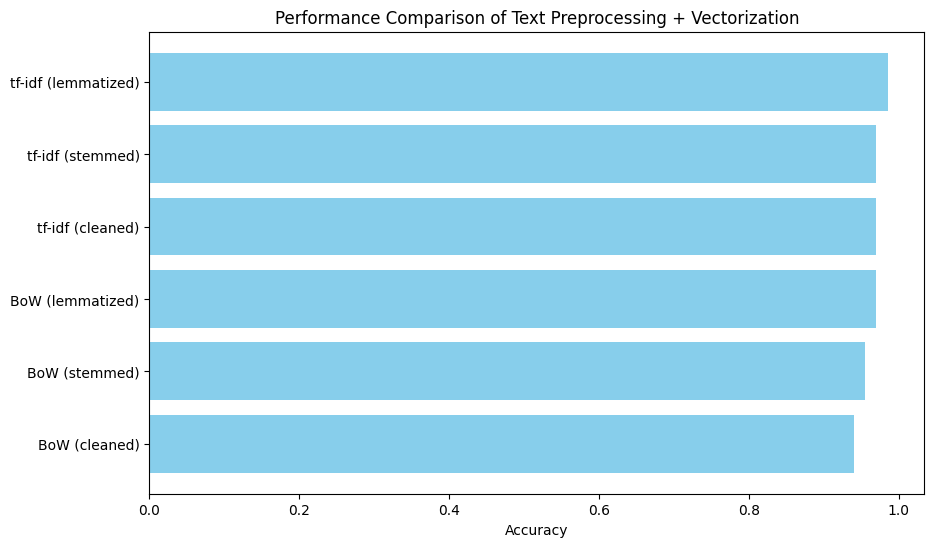

In [16]:
import matplotlib.pyplot as plt

# collect accuracies into a dict for plotting
results = {
	'BoW (cleaned)': acc_bow_cleaned,
	'BoW (stemmed)': acc_bow_stemmed,
	'BoW (lemmatized)': acc_bow_lemmatized,
	'tf-idf (cleaned)': acc_tfidf_cleaned,
	'tf-idf (stemmed)': acc_tfidf_stemmed,
	'tf-idf (lemmatized)': acc_tfidf_lemmatized
}

plt.figure(figsize=(10,6))
plt.barh(list(results.keys()), list(results.values()), color='skyblue')
plt.xlabel('Accuracy')
plt.title('Performance Comparison of Text Preprocessing + Vectorization')
plt.show()
